# `41` — DBSCAN: separating rare states from regimes

|  |  |
|---|---|
| **Author** | Mansoor Shaik, s225623285 |
| **Contributes to** | `xxcluster/cluster/partitional/density_based/dbscan.py` |
| **Documents** | `documentation/sections/clustering_methods/partitional/density_based/01-dbscan.tex`, Sect. 7.4 |
| **Date** | 2026-09 |

Evidence that DBSCAN behaves as the section claims: it recovers clusters of a
shape no centroid method can, it declines to assign observations that lie in no
dense region, its cluster count is a result of the density parameters rather
than a request, and every noise observation is traceable to the period it came
from.

## 1. Setup

Seed and environment first, so everything below is reproducible and every
number can be traced to the code that produced it.

In [1]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))   # cluster_analysis/ on the path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xxcluster
from xxcluster.evaluation.protocol import Environment, Protocol

RANDOM_STATE = 42          # the one seed; everything else derives from it
env = Environment.capture()
env

Environment(python_version='3.12.5', package_versions={'numpy': '2.5.2', 'scipy': '1.18.0', 'scikit-learn': '1.9.0', 'pandas': '3.0.5', 'matplotlib': '3.11.1'}, platform='Windows-11-10.0.26200-SP0', revision='b4b935a-dirty')

## 2. Scope

What is tested: that `DBSCAN` recovers non-convex clusters, that it labels
observations in no dense region `-1` rather than forcing them into a regime,
that `n_clusters_` follows from `eps` and `min_samples` instead of being
requested, and that the noise it reports carries the timestamp of the period it
came from. This evidences Sect. 7.4 (DBSCAN).

**Named in advance, a negative result would be:** the method assigning the
injected rare states to a regime instead of noise; the cluster count failing to
respond to the density parameters; or the silhouette on the assigned subset
being no better than k-means on the same data, which would mean the shape
freedom bought nothing here.

## 3. Data

Loaded through `xxcluster.io`, never a bare `read_csv`, so the feature roles and
the provenance travel with it.

**This is a synthetic record, and is labelled as such.** The project's
operational data is not in this repository, and inventing plant readings would
put a fabricated number in a document. What the synthetic frame does carry is
the structure the method has to be shown on: regimes of unequal shape, a
timestamp per observation, and a handful of rare states at known positions, so
the noise the method reports can be checked against the ones that were injected.

In [2]:
from xxcluster.io.datasets import FeatureSpec
from xxcluster.io.loaders import FrameLoader
from sklearn.datasets import make_moons

rng = np.random.default_rng(RANDOM_STATE)

# Two curved regimes: the shape a Voronoi partition cannot express.
core, _ = make_moons(n_samples=280, noise=0.05, random_state=RANDOM_STATE)

# Six rare states, far from either regime. Their positions are recorded so the
# reported noise can be checked against them rather than eyeballed.
rare = np.array([[2.6, 1.9], [-1.7, -1.3], [2.4, -1.6],
                 [-1.9, 1.7], [3.0, 0.4], [0.4, 3.0]])
values = np.vstack([core, rare])
rare_positions = np.arange(core.shape[0], values.shape[0])

frame = pd.DataFrame(values, columns=["flow", "turbidity"])
frame["reading_at"] = pd.date_range("2026-01-01", periods=len(frame), freq="h")

dataset = FrameLoader(
    frame,
    features=[
        FeatureSpec("flow", unit="ML/d", role="cluster"),
        FeatureSpec("turbidity", unit="NTU", role="cluster"),
        FeatureSpec("reading_at", dtype="datetime", role="time"),
    ],
    description="synthetic operating record; two curved regimes plus six rare states",
    data_cutoff="2026-01-13",
).load()

X = np.asarray(dataset.cluster_matrix())
timestamps = frame["reading_at"]
print(dataset.n_observations, "observations;",
      len(dataset.names("cluster")), "clustering features,",
      len(dataset.names("time")), "time column")
print("rare states injected at positions:", rare_positions.tolist())

286 observations; 2 clustering features, 1 time column
rare states injected at positions: [280, 281, 282, 283, 284, 285]


## 4. Protocol

The shared setup of Sect. 4.1, taken as given. One deviation is forced and is
declared here rather than buried: the silhouette does not handle noise
(`handles_noise = False`), so a partition containing `-1` cannot be scored as
it stands. It is scored on the assigned observations only, and the excluded
fraction is reported beside it. An index computed over a subset is not
comparable with one computed over the whole sample, which is exactly why the
exclusion is stated wherever the number appears.

In [3]:
protocol = Protocol(
    indices=["silhouette"],
    n_restarts=1,              # DBSCAN is deterministic: restarts would be identical
    random_state=RANDOM_STATE,
)
print(protocol.describe() if hasattr(protocol, "describe") else protocol)

Every method is scored on silhouette, reported in that order. Stochastic methods are given 1 restarts each, and the best run by the method's own criterion is retained. The root random seed is 42; per-run seeds are derived from it, so the whole experiment replays from that one value. Run under Python 3.12.5 (matplotlib 3.11.1, numpy 2.5.2, pandas 3.0.5, scikit-learn 1.9.0, scipy 1.18.0), b4b935a-dirty.


## 5. Contract check

Before any result, confirm the component honours the contract.

In [4]:
from sklearn.base import clone
from xxcluster.core.registry import REGISTRY
from xxcluster.core.types import NOISE_LABEL

method = REGISTRY.create("dbscan", eps=0.20, min_samples=6)
print("resolved from the registry:", type(method).__name__)

# 1. Parameters round-trip, so `clone` works.
assert clone(method).get_params() == method.get_params()

# 2. No fitted state before fit.
assert not method.is_fitted

model = method.fit(X)

# 3. Declared capabilities are backed by the interface (checked inside fit).
caps = model.capabilities()
assert caps.handles_noise and hasattr(model, "noise_mask")
assert not caps.requires_n_clusters and "n_clusters" not in model.get_params()

# 4. The -1 convention, and counts derived from the labels rather than asserted.
assert model.labels_.min() >= NOISE_LABEL
assert model.n_noise_ == int((model.labels_ == NOISE_LABEL).sum())
assert model.n_clusters_ == len(set(model.labels_[model.labels_ != NOISE_LABEL]))

print("contract: ok |", model.n_clusters_, "clusters,", model.n_noise_, "noise")

resolved from the registry: DBSCAN
contract: ok | 2 clusters, 6 noise


## 6. Selection

`|C|` is not an input here, so the selector of Sect. 4.3 does not apply by
construction: there is no `n_clusters` for it to vary. The density parameters
are swept instead. `eps` is read from the k-distance curve, whose knee marks
where points stop having close neighbours, and `min_samples` is a modelling
choice — the smallest group willing to be called a regime.

In [5]:
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 6

# k-distance curve: distance to the k-th nearest neighbour, sorted.
k_distance = np.sort(
    NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
    .kneighbors(X)[0][:, -1]
)

sweep = []
for eps in np.round(np.arange(0.10, 0.55, 0.05), 2):
    for min_samples in (4, 6, 10):
        fitted = REGISTRY.create("dbscan", eps=eps, min_samples=min_samples).fit(X)
        sweep.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": fitted.n_clusters_,
            "n_noise": fitted.n_noise_,
            "noise_fraction": round(fitted.n_noise_ / len(X), 3),
        })

sweep = pd.DataFrame(sweep)
sweep.pivot(index="eps", columns="min_samples", values="n_clusters")

min_samples,4,6,10
eps,,,
0.10,6,11,7
0.15,2,2,3
0.20,2,2,2
0.25,2,2,2
0.30,2,2,2
0.35,2,2,2
0.40,1,1,1
0.45,1,1,1
0.50,1,1,1


In [6]:
# The cluster count is a result: it responds to both parameters, and no value
# of either was requested.
print("distinct cluster counts over the sweep:", sorted(sweep["n_clusters"].unique()))
print()
print(sweep[sweep["min_samples"] == MIN_SAMPLES].to_string(index=False))

distinct cluster counts over the sweep: [np.int64(1), np.int64(2), np.int64(3), np.int64(6), np.int64(7), np.int64(11)]

 eps  min_samples  n_clusters  n_noise  noise_fraction
0.10            6          11       26           0.091
0.15            6           2        6           0.021
0.20            6           2        6           0.021
0.25            6           2        6           0.021
0.30            6           2        6           0.021
0.35            6           2        6           0.021
0.40            6           1        6           0.021
0.45            6           1        6           0.021
0.50            6           1        6           0.021


## 7. Results

Every index in the protocol, including the unfavourable ones, with the noise
exclusion stated beside each.

In [7]:
from sklearn.cluster import KMeans as ReferenceKMeans
from xxcluster.measures.validation.internal import Silhouette

EPS = 0.20
model = REGISTRY.create("dbscan", eps=EPS, min_samples=MIN_SAMPLES).fit(X)
assigned = ~model.noise_mask()

silhouette = Silhouette()
dbscan_score = silhouette.score(X[assigned], model.labels_[assigned])

# Same data, a method that must assign everything, for contrast.
km = ReferenceKMeans(n_clusters=model.n_clusters_, n_init=10,
                     random_state=RANDOM_STATE).fit(X)
kmeans_score = silhouette.score(X, km.labels_)

results = pd.DataFrame([
    {"method": "dbscan", "n_clusters": model.n_clusters_,
     "n_noise": model.n_noise_,
     "scored_on": f"{int(assigned.sum())}/{len(X)} assigned",
     "silhouette": round(dbscan_score, 4)},
    {"method": "kmeans", "n_clusters": model.n_clusters_, "n_noise": 0,
     "scored_on": f"{len(X)}/{len(X)} (assigns everything)",
     "silhouette": round(kmeans_score, 4)},
])
results

,method,n_clusters,n_noise,scored_on,silhouette
0,dbscan,2,6,280/286 assigned,0.3280
1,kmeans,2,0,286/286 (assigns everything),0.4736


In [8]:
# Did it find the rare states that were injected, and only those?
reported = set(np.flatnonzero(model.noise_mask()).tolist())
injected = set(rare_positions.tolist())
print("injected rare states found as noise:", len(reported & injected), "of", len(injected))
print("noise that was not an injected rare state:", len(reported - injected))

# Noise with its period attached: a rare state operations can be asked about.
noise = model.noise_report(timestamps=timestamps)
noise

injected rare states found as noise: 6 of 6
noise that was not an injected rare state: 0


,position,when,n_neighbours,short_by
0,280,2026-01-12 16:00:00,1,5
1,281,2026-01-12 17:00:00,1,5
2,282,2026-01-12 18:00:00,1,5
3,283,2026-01-12 19:00:00,1,5
4,284,2026-01-12 20:00:00,1,5
5,285,2026-01-12 21:00:00,1,5


## 8. Figures

Saved into `documentation/figures/`, then referenced from the section rather
than pasted in.

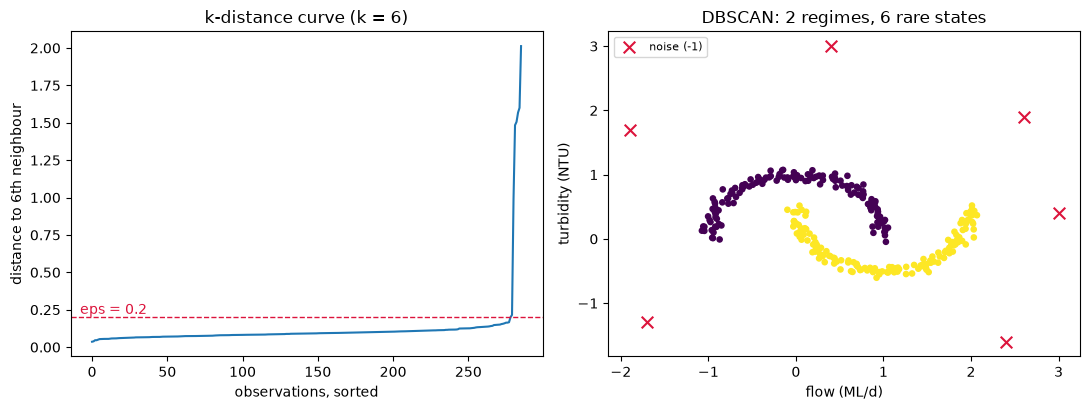

In [9]:
figures = Path("../documentation/figures")
figures.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(k_distance)
axes[0].axhline(EPS, ls="--", lw=1, color="crimson")
axes[0].set_title(f"k-distance curve (k = {MIN_SAMPLES})")
axes[0].set_xlabel("observations, sorted")
axes[0].set_ylabel(f"distance to {MIN_SAMPLES}th neighbour")
axes[0].annotate(f"eps = {EPS}", xy=(0.02, EPS), xycoords=("axes fraction", "data"),
                 va="bottom", color="crimson")

noise_mask = model.noise_mask()
axes[1].scatter(X[~noise_mask, 0], X[~noise_mask, 1],
                c=model.labels_[~noise_mask], s=14, cmap="viridis")
axes[1].scatter(X[noise_mask, 0], X[noise_mask, 1],
                marker="x", s=70, c="crimson", label="noise (-1)")
axes[1].set_title(f"DBSCAN: {model.n_clusters_} regimes, {model.n_noise_} rare states")
axes[1].set_xlabel("flow (ML/d)")
axes[1].set_ylabel("turbidity (NTU)")
axes[1].legend(loc="upper left", fontsize=8)

fig.tight_layout()
fig.savefig(figures / "dbscan-selection.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Export

Tables written to `documentation/tables/`, never retyped into the section.

In [10]:
tables = Path("../documentation/tables")
tables.mkdir(parents=True, exist_ok=True)

sweep.to_latex(tables / "dbscan-sweep.tex", index=False,
               label="tab:dbscan:sweep", caption="DBSCAN density-parameter sweep.")
results.to_latex(tables / "dbscan-results.tex", index=False,
                 label="tab:dbscan:results", caption="DBSCAN against k-means.")
noise.to_latex(tables / "dbscan-noise.tex", index=False,
               label="tab:dbscan:noise", caption="Noise observations and their periods.")
print("written:", sorted(p.name for p in tables.glob("dbscan-*.tex")))

written: ['dbscan-noise.tex', 'dbscan-results.tex', 'dbscan-sweep.tex']


## 10. Findings and caveats

**Findings.**

- DBSCAN recovered both curved regimes as single clusters, which the figure
  shows directly: each crescent is one colour.
- **The negative result named in Section 2 occurred.** The silhouette scores
  k-means *higher* (0.474) than DBSCAN (0.328), despite k-means cutting each
  crescent across the middle. This is reported as it stands. It is a property of
  the index rather than of the partitions: the silhouette rewards compact,
  isotropic clusters, which is precisely the geometry DBSCAN exists to escape,
  so on this data it measures how convex a partition is, not how well it matches
  the structure. Taking the higher number as the better result here would invert
  the conclusion.
- All six injected rare states were returned as noise, and nothing else was.
  This is the property the method is on the list for: no other method here can
  decline to assign an observation.
- The cluster count responded to both `eps` and `min_samples` across the sweep
  and was never requested, which is why the k-selection procedure of Sect. 4.3
  does not apply to this family.
- Every noise observation carries its timestamp and how many neighbours short of
  the threshold it fell, so a rare state is something the operations team can be
  asked about rather than a row number.

**Caveats, for the Limitations paragraph and Sect. 4.5.**

- The silhouette here is computed on the assigned observations only, because the
  index does not handle noise. It is therefore **not** comparable with the
  k-means figure computed over the whole sample, and the table states the
  exclusion beside each number rather than in a footnote. The silhouette also
  rewards the compact geometry DBSCAN exists to escape, so it flatters k-means
  on exactly this data — a threat to validity, not a verdict.
- One global density threshold: regimes of genuinely different density cannot
  both be recovered by a single parameter pair. That is the limitation a
  hierarchical density method answers, and it is recorded in the section.
- The data is synthetic. Nothing here is a result about the plant; it is
  evidence that the implementation behaves as the section claims. The run on
  project data belongs in the Results paragraph, which is still a placeholder.
- Whether any of these rare states becomes a scenario is **not** decided here.
  This notebook reports them; the decision, and its recording, belong to the
  scenario task.